# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

**After reading the provided links and articles, this data represents a total of 17 marketing campaigns.**

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [20]:
import pandas as pd

In [ ]:
df = pd.read_csv('data/bank-additional-full.csv', sep = ';')

In [ ]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



**After examining the data, there are no strictly missing values such as the data field being completely empty (NaN). Every column contains 41188 non-null data.**

**However, it seems that in place of missing values, the value of "unknown" is assigned, effectively acting as NaN since these values give no use in interpreting/processing the data.**

**These rows may need to be removed to utilize full data interpretability. Additionally, consider removing the duration category as according to the descriptions above, the duration is not known before a call is performed and can be removed to ensure a more realistic predictive model.**

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

### BUSINESS OBJECTIVE
**After examining the description and data, the business objective is to use ML to predict if a client will subscribe to a term deposit for a Portuguese banking institution via direct marketing campaigns (phone calls). By analyzing and interpreting the results of this predictive model, the bank can optimize and tailor its marketing campaign strategies to those who are most likely to subscribe to a term deposit. This can greatly contribute to increased success in gaining subscriptions, and an overall rise in time and cost efficiency.**

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

X = df[['age', 'job', 'marital', 'education', 'default', 'housing', 'loan']]
y = df['y'].map({'no': 0, 'yes': 1})

categorical_features = ['job', 'marital', 'education', 'default', 'housing', 'loan']
numeric_features = ['age']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ])

X_processed = preprocessor.fit_transform(X)

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.3, random_state=42, stratify=y)

### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
baseline_acc = accuracy_score(y_test, dummy.predict(X_test))
print(baseline_acc)

0.8873512988589464


**Utilizing a Dummy Classifier to use a simple baseline to compare with other classifiers, we can come up with a score of accuracy on the test set. In this case, the baseline score is around 89% (majority of the results are 'no')**

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

### Problem 9: Score the Model

What is the accuracy of your model?

In [ ]:
acc = lr.score(X_test, y_test)
print(acc)

0.8873512988589464


**The accuracy of the model is also around 89%**

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
import time
import pandas as pd

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'SVM': SVC()
}

results = []
for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start
    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)
    results.append({'Model': name, 'Train Time': train_time, 'Train Accuracy': train_acc, 'Test Accuracy': test_acc})

pd.DataFrame(results)

,Model,Train Time,Train Accuracy,Test Accuracy
0,Logistic Regression,0.187074,0.887343,0.887351
1,KNN,0.007188,0.892338,0.878692
2,Decision Tree,0.426898,0.918837,0.864368
3,SVM,54.777437,0.888315,0.887028


### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

In [ ]:
X_full = df.drop(columns=['y', 'duration'])
y = df['y'].map({'no': 0, 'yes': 1})

categorical_features = X_full.select_dtypes(include='object').columns.tolist()
numeric_features = X_full.select_dtypes(include=['int64', 'float64']).columns.tolist()

preprocessor_full = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ])

X_processed_full = preprocessor_full.fit_transform(X_full)

X_train_full, X_test_full, y_train, y_test = train_test_split(X_processed_full, y, test_size=0.3, random_state=42, stratify=y)

In [22]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.metrics import f1_score, make_scorer
from scipy.stats import loguniform
import time

f1_scorer = make_scorer(f1_score)
results = []

# Logistic REgression
start = time.time()
grid_lgr = GridSearchCV(
    LogisticRegression(max_iter=2000),
    {'C': [0.01, 0.1, 1, 10], 'solver': ['lbfgs', 'liblinear']},
    cv=5, scoring=f1_scorer, n_jobs=-1)
grid_lgr.fit(X_train_full, y_train)
fit_time = time.time() - start
results.append({
    'Model': 'LogisticRegression',
    'Best Params': grid_lgr.best_params_,
    'CV F1': grid_lgr.best_score_,
    'Test F1': f1_score(y_test, grid_lgr.predict(X_test_full)),
    'Fit Time (s)': fit_time
})

# KNN
start = time.time()
grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    {'n_neighbors': [3, 5, 7, 9], 'weights': ['uniform', 'distance']},
    cv=5, scoring=f1_scorer, n_jobs=-1)
grid_knn.fit(X_train_full, y_train)
fit_time = time.time() - start
results.append({
    'Model': 'KNN',
    'Best Params': grid_knn.best_params_,
    'CV F1': grid_knn.best_score_,
    'Test F1': f1_score(y_test, grid_knn.predict(X_test_full)),
    'Fit Time (s)': fit_time
})

# Decision Tree
start = time.time()
grid_tree = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    {'max_depth': [3, 5, 7, None], 'min_samples_split': [2, 5, 10]},
    cv=5, scoring=f1_scorer, n_jobs=-1)
grid_tree.fit(X_train_full, y_train)
fit_time = time.time() - start
results.append({
    'Model': 'DecisionTree',
    'Best Params': grid_tree.best_params_,
    'CV F1': grid_tree.best_score_,
    'Test F1': f1_score(y_test, grid_tree.predict(X_test_full)),
    'Fit Time (s)': fit_time
})

# SVM
start = time.time()
grid_linear = GridSearchCV(
    LinearSVC(max_iter=5000, dual=False), # using linearSVC for SVM, SVC() times out execution on my computer
    {'C': [0.01, 0.1, 1, 10]},
    cv=5, scoring=f1_scorer, n_jobs=-1)
grid_linear.fit(X_train_full, y_train)
fit_time = time.time() - start
results.append({
    'Model': 'LinearSVC',
    'Best Params': grid_linear.best_params_,
    'CV F1': grid_linear.best_score_,
    'Test F1': f1_score(y_test, grid_linear.predict(X_test_full)),
    'Fit Time (s)': fit_time
})
pd.DataFrame(results).round(4)

,Model,Best Params,CV F1,Test F1,Fit Time (s)
0,LogisticRegression,"{'C': 10, 'solver': 'lbfgs'}",0.3423,0.3342,8.7676
1,KNN,"{'n_neighbors': 3, 'weights': 'uniform'}",0.3621,0.3773,237.0852
2,DecisionTree,"{'max_depth': 7, 'min_samples_split': 2}",0.3761,0.3805,21.2601
3,LinearSVC,{'C': 10},0.3217,0.3188,4.1499


## RESULTS

### DECISION TREES
Analyzing the results, it seems that **Decision Tree** is the best model to use. With the highest F1 scoreof round 0.38, it would be the best model to find likely subscribers to the term deposit. However, training time is the second worst out of the 4 coming in at around 21 seconds. Additionally, due to the nature of decision trees, it can be unstable with data changes and interpretability is at the mercy of the simplicity of rules.

### LOGISTIC REGRESSION
Logistic Regression suffers from lower F1 score (around 0.34) which is not ideal for identifying potential subscribers. However, training time is the second best out of the four models and it is very stable. I believe this would also be a good choice due to its stability and high interpretability. However, Logistic Regression by its nature assumes linear relationships and may miss more complex patterns



### KNN
KNN may not be recommended. Training time is dramatically higher than the other models by a wide margin. However, F1 score is second highest only beaten by decision trees. So in this case, a tradeoff between accuracy and time consideration needs to be taken into account. Overall, I would not recommend KNN due to its weakness to imbalanced data, sensitivity to scaling and very memory-intensive compute time which to a non-technical stakeholder I would imagine does not sound ideal.

### LINEARSVC
Linear SVC may also not be recommended. It has the lowest F1 score which right away identifies itself as the worst model in regards to precision in predicting the best potential subscribers. However, training time is extremely good at only 4 seconds. Additionally, inherent characteristics of this model gives benefits such as robustness to outliers and high scalability while suffering from less interpretability compare to Logistic Regression. Overall, I would still not recommend Linear SVC due to its very poor performance in accuracy which I would say is more important than training time.

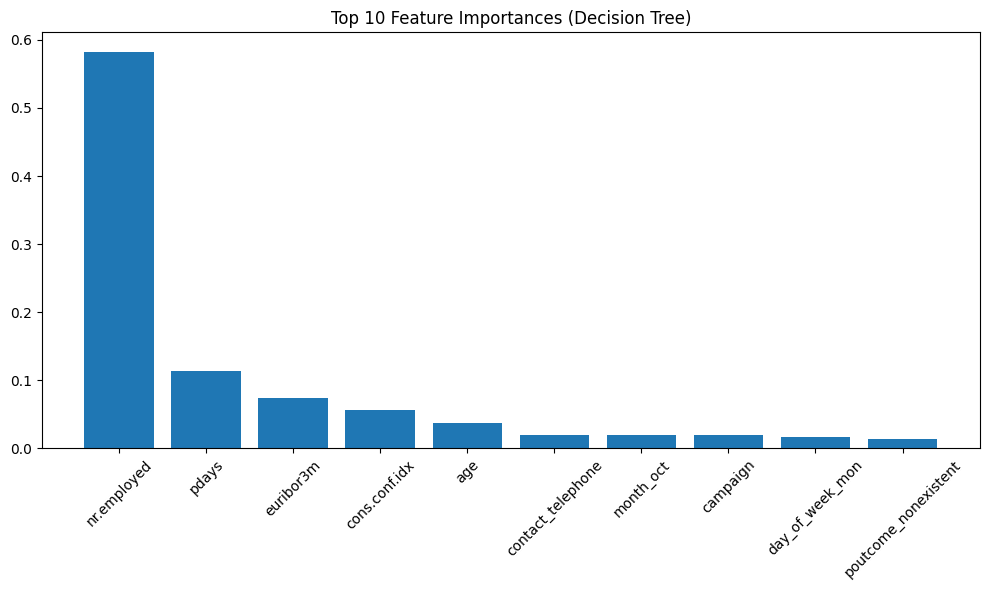

In [24]:
import matplotlib.pyplot as plt

# Feature importance (using full feature names)
feature_names = (numeric_features +
                 preprocessor_full.named_transformers_['cat']
                 .get_feature_names_out(categorical_features).tolist())

importances = grid_tree.best_estimator_.feature_importances_
indices = importances.argsort()[::-1]

plt.figure(figsize=(10, 6))
plt.title("Top 10 Feature Importances (Decision Tree)")
plt.bar(range(10), importances[indices[:10]])
plt.xticks(range(10), [feature_names[i] for i in indices[:10]], rotation=45)
plt.tight_layout()
plt.show()

## CONCLUSION
In conclusion, the best model to use would be Decision Tree for the best results regarding predictive accuracy, which is most important overall. In addition, Logistic Regression may also be a good choice for baseline explanation and interpretability to non-technical stakeholders. Although, this alternative will not be the best choice in terms of precision in identifying potential subscribers.

Some actionable insights include:


*   Call clients when the job market is strong (high number of employed from quarterly indicators)
*   Call clients not too long after the previous call. The call will be more successful the sooner the client is contacted again.

*   Call clients when euribor rates are low
*   Call clients who are middle-aged to senior citizens

*   Call clients in the month of October. This is the best time for the best potential for subscriptions.





